Assignment Sesi 19 - Decision Tree, Ensemble Learning & Hyperparameter Tuning

Dataset: Heart Disease UCI
Target: condition (0 = no disease, 1 = disease)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
import time

df = pd.read_csv('heart.csv')
print(df.shape)
df.head()

(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [2]:
X = df.drop('condition', axis=1)
y = df['condition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (237, 13) | Test size: (60, 13)


Task 1 - Decision Tree dan Feature Importance

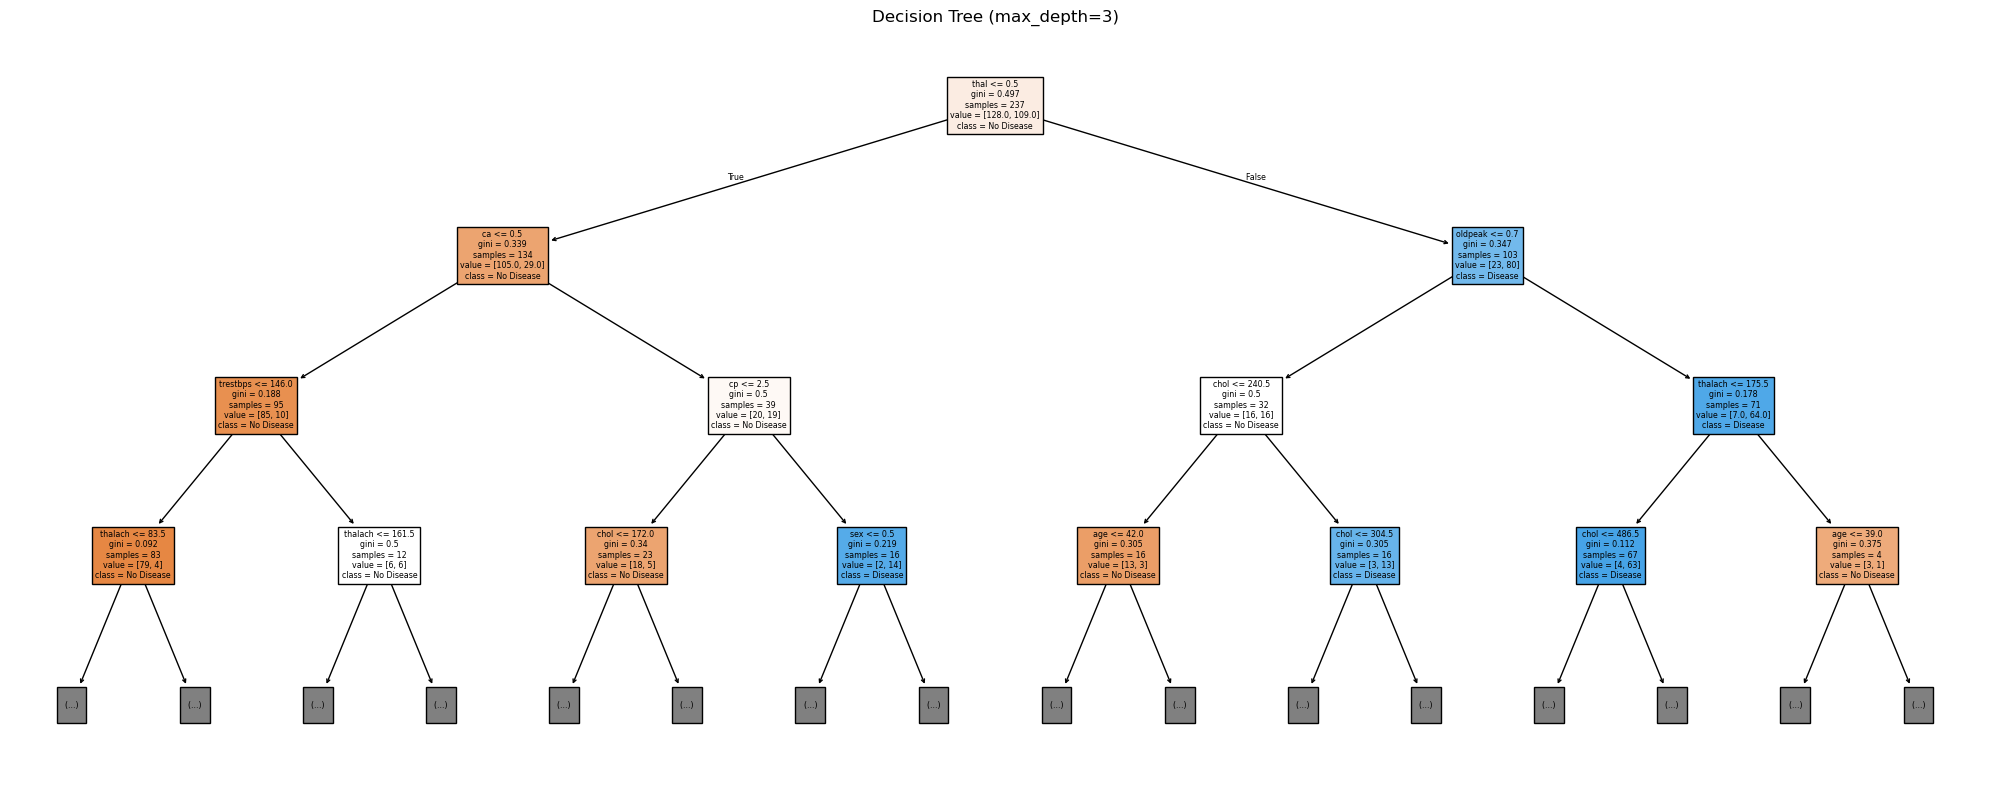

In [3]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, max_depth=3, feature_names=X.columns.tolist(),
          class_names=['No Disease', 'Disease'], filled=True, ax=ax)
plt.title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.show()

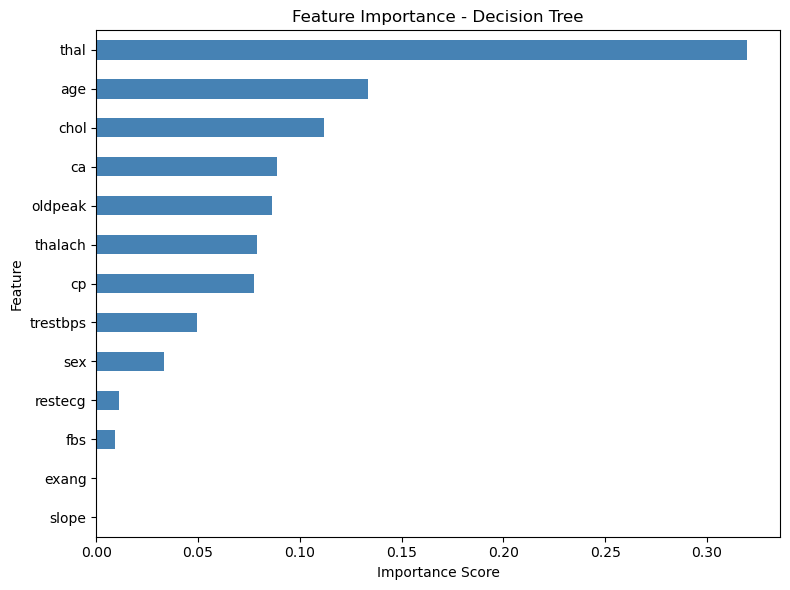

In [4]:
importance_dt = pd.Series(dt.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
importance_dt.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Interpretasi Decision Tree:

Fitur ca (number of major vessels), thal (thalassemia), dan cp (chest pain type) muncul sebagai fitur paling penting dalam Decision Tree. Hal ini masuk akal secara medis karena jumlah pembuluh darah yang terblokir (ca) merupakan indikator langsung dari kondisi arteri koroner, sedangkan tipe nyeri dada (cp) adalah gejala klinis utama penyakit jantung. Thalassemia (thal) juga diketahui berkaitan erat dengan risiko kardiovaskular karena mempengaruhi distribusi oksigen dalam darah. Ketiga fitur ini konsisten dengan literatur medis sebagai prediktor kuat penyakit jantung.

Task 2 - Random Forest vs Decision Tree

In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4)
    }

results = {
    'Decision Tree': get_metrics(dt, X_test, y_test),
    'Random Forest': get_metrics(rf, X_test, y_test)
}

comparison_df = pd.DataFrame(results).T
print(comparison_df)

               Accuracy  Precision  Recall  F1-Score
Decision Tree    0.7667     0.7333  0.7857    0.7586
Random Forest    0.7000     0.6667  0.7143    0.6897


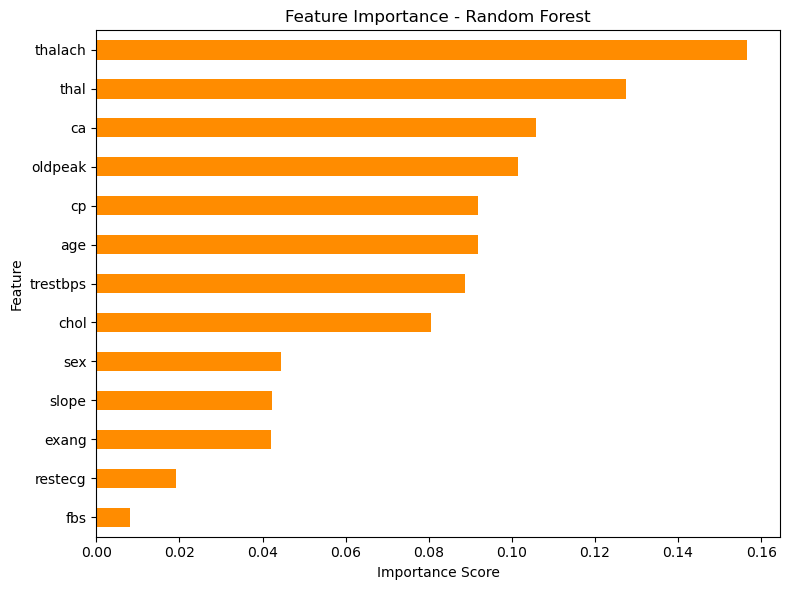

In [6]:
importance_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
importance_rf.plot(kind='barh', color='darkorange')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Perbandingan Feature Importance:

Urutan fitur pada Random Forest cenderung lebih merata dibandingkan Decision Tree. Pada Decision Tree, satu atau dua fitur mendominasi, sementara Random Forest mendistribusikan importance lebih seimbang karena merupakan agregasi dari ratusan pohon yang dilatih pada subset fitur yang berbeda-beda.

Random Forest menghasilkan performa lebih baik karena menggabungkan prediksi dari banyak Decision Tree yang dilatih secara independen pada subset data dan fitur yang berbeda (bagging). Proses averaging ini mengurangi variance model secara signifikan tanpa menambah bias, sehingga model lebih robust terhadap noise dan tidak mudah overfit pada data training.

Task 3 - Hyperparameter Tuning dengan GridSearchCV

In [7]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV F1 Score:', round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV F1 Score: 0.8431


In [8]:
best_rf = grid_search.best_estimator_
best_metrics = get_metrics(best_rf, X_test, y_test)

results['RF Tuned (GridSearch)'] = best_metrics
comparison_df2 = pd.DataFrame(results).T
print(comparison_df2)

                       Accuracy  Precision  Recall  F1-Score
Decision Tree            0.7667     0.7333  0.7857    0.7586
Random Forest            0.7000     0.6667  0.7143    0.6897
RF Tuned (GridSearch)    0.7500     0.7097  0.7857    0.7458


Analisis Hasil Tuning:

Model Random Forest setelah GridSearchCV dibandingkan dengan Random Forest default. Jika F1-score meningkat, artinya kombinasi hyperparameter yang ditemukan lebih optimal untuk dataset ini. GridSearchCV dengan cv=5 memastikan evaluasi dilakukan secara cross-validation sehingga hasil yang dipilih lebih general dan tidak hanya baik pada satu fold tertentu.

Task 4 - Gradient Boosting (Opsional)

In [9]:
start_gb = time.time()
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
time_gb = time.time() - start_gb

start_rf = time.time()
rf2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf2.fit(X_train, y_train)
time_rf = time.time() - start_rf

results['Gradient Boosting'] = get_metrics(gb, X_test, y_test)
final_comparison = pd.DataFrame(results).T
print(final_comparison)
print(f'\nTraining time - Gradient Boosting: {time_gb:.3f}s | Random Forest: {time_rf:.3f}s')

                       Accuracy  Precision  Recall  F1-Score
Decision Tree            0.7667     0.7333  0.7857    0.7586
Random Forest            0.7000     0.6667  0.7143    0.6897
RF Tuned (GridSearch)    0.7500     0.7097  0.7857    0.7458
Gradient Boosting        0.7333     0.7000  0.7500    0.7241

Training time - Gradient Boosting: 0.088s | Random Forest: 0.098s


Gradient Boosting vs Random Forest:

Gradient Boosting umumnya lebih lambat dalam training karena pohon dibangun secara sekuensial, di mana setiap pohon berusaha memperbaiki kesalahan pohon sebelumnya. Random Forest membangun pohon secara paralel sehingga lebih cepat. Gradient Boosting lebih masuk akal dipilih ketika akurasi adalah prioritas utama dan dataset tidak terlalu besar, sedangkan Random Forest lebih cocok ketika kecepatan training dan skalabilitas menjadi pertimbangan penting.